In [56]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [71]:
# ============================================================================
# CELL 1: LLM Query Function
# ============================================================================

import requests
import json

def get_strategy_from_llm(iteration):
    """
    Queries the local Ollama Llama3:8b model to suggest an optimization strategy.
    
    Args:
        iteration (int): The current iteration number of the algorithm.
        
    Returns:
        int: The chosen strategy number (1-5).
    """
    prompt = f"""Select strategy for knapsack optimization iteration {iteration}/100.

Phase: {"Early" if iteration < 20 else "Mid" if iteration < 60 else "Late" if iteration < 90 else "Final"}

Strategies:
1 = Balanced exploration (early phase, need diversity)
2 = Objective specialization (mid phase, extreme solutions)
3 = Gap filling (always good, improve weak objective)
4 = Aggressive exploitation (late phase, high quality only)
5 = Random perturbation (if stuck)

Reply with ONE number (1-5):"""

    url = "http://localhost:11434/api/generate"
    payload = {
        "model": "llama3:8b",
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0.7,
            "max_tokens": 10
        }
    }
    
    try:
        response = requests.post(url, json=payload, timeout=40)
        if response.status_code == 200:
            result = response.json()
            response_text = result.get('response', '')
            for char in response_text:
                if char.isdigit():
                    strategy = int(char)
                    return min(max(strategy, 1), 5)
            print(f"Warning: LLM response '{response_text}' did not contain a number. Defaulting to strategy 1.")
            return 1
        else:
            print(f"Error connecting to Ollama: {response.status_code} - {response.text}")
            return 1
    except requests.exceptions.RequestException as e:
        print(f"Error getting strategy from LLM: {e}. Is Ollama running?")
        return 1

# Test the function
print("Testing LLM connection...")
strategy = get_strategy_from_llm(50)
print(f"LLM suggested strategy: {strategy}")

Testing LLM connection...
LLM suggested strategy: 2


In [68]:
%%cython

# ============================================================================
# CELL 2: HYBRID LLM-MOACP - WITH LLM PERTURBATION LOGIC
# ============================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp
import time

cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# ============================================================================
# GLOBAL VARIABLES
# ============================================================================

cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# Statistics
cdef int current_iteration = 0

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

# ============================================================================
# POPULATION MANAGEMENT
# ============================================================================

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    cdef int i
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

# ============================================================================
# PARETO DOMINANCE
# ============================================================================

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

# ============================================================================
# EPSILON INDICATOR & FITNESS
# ============================================================================

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# ============================================================================
# FILE I/O
# ============================================================================

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

# ============================================================================
# INITIALIZATION & EVALUATION
# ============================================================================

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

# ============================================================================
# ARCHIVE MANAGEMENT
# ============================================================================

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_bound

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

# ============================================================================
# SELECTION
# ============================================================================

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# ============================================================================
# HELPER TO GET BEST SOLUTION FOR LLM
# ============================================================================


cdef dict get_best_solution_info(pop *archive):
    """Returns a dict with info of the first solution in the archive, including item lists."""
    cdef dict info = {'f1': 0.0, 'f2': 0.0, 'items_in': [], 'items_out': []}
    cdef int i
    if archive.size > 0:
        s = archive.ind_array[0]
        info['f1'] = s.f[0]
        info['f2'] = s.f[1]
        # Create lists of item IDs
        for i in range(ni):
            if s.Items[i] == 1:
                info['items_in'].append(i)
            else:
                info['items_out'].append(i)
    return info

# ============================================================================
# HYBRID LOCAL SEARCH - WITH PERTURBATION LOGIC
# ============================================================================

# In Cell 2, replace the `Indicator_local_search1_hybrid` function with this:

# In Cell 2, replace the `Indicator_local_search1_hybrid` function with this FINAL version:

cdef void Indicator_local_search1_hybrid(pop *SP, pop *Sarchive, int size, dict strategy_dict):
    """
    Hybrid local search. Uses default random search or an LLM-guided suggestion.
    This version has the CORRECT swap logic.
    """
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, l, sol, mino, consistant, taille, feasible, tv
    cdef int convergence, tmp_pris, tmp_nonpris
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    cdef list selected_items
    cdef int strategy_code
    cdef int suggestion_type, k, item_to_remove, item_to_add
    cdef double best_gain, current_gain
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    strategy_code = strategy_dict.get('code', 0)
    
    
    # *** NEW: LLM GUIDED SUGGESTION LOGIC WITH MEMORY ***
    if strategy_code == -1:
        print("[CYTHON] Applying LLM-guided suggestion...")
        suggestion_type = strategy_dict.get('suggestion_type', 0)
        memory_set = strategy_dict.get('memory', set())
        
        best_gain = -1e9
        item_to_remove = -1
        item_to_add = -1
        
        x = SP.ind_array[0]
        
        # Iterate through all items to REMOVE
        for i in range(ni):
            if x.Items[i] == 1:
                # Iterate through all items to ADD
                for j in range(ni):
                    if x.Items[j] == 0:
                        # NEW: Check if this swap was already suggested
                        if (i, j) in memory_set:
                            continue # Skip this swap
                        
                        # Check if the swap is FEASIBLE
                        feasible = 1
                        for k in range(nf):
                            if x.capa[k] - weights[k][i] + weights[k][j] > capacities[k]:
                                feasible = 0
                                break
                        
                        if feasible:
                            # Calculate the GAIN
                            current_gain = profits[suggestion_type][j] - profits[suggestion_type][i]
                            
                            if current_gain > best_gain:
                                best_gain = current_gain
                                item_to_remove = i
                                item_to_add = j
        
        # Perform the best swap if found
        if item_to_remove != -1 and item_to_add != -1:
            x.Items[item_to_remove] = 0
            x.Items[item_to_add] = 1
            for k in range(nf):
                x.capa[k] = x.capa[k] - weights[k][item_to_remove] + weights[k][item_to_add]
                x.f[k] = x.f[k] - profits[k][item_to_remove] + profits[k][item_to_add]
            
            # NEW: Add the successful swap to the memory set
            memory_set.add((item_to_remove, item_to_add))
            
            print(f"[CYTHON] LLM-guided swap applied: REMOVED {item_to_remove}, ADDED {item_to_add} with gain {best_gain:.2f}")
        else:
            print("[CYTHON] LLM-guided suggestion could not find a new, feasible, or improving swap.")

    # OUTER WHILE LOOP (Standard Search)
    while True:
        convergence = 0
        # MIDDLE FOR LOOP
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                # INNER WHILE LOOP
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    # 1. Remove one item
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    
                    # 2. Select items to add using the ORIGINAL RANDOM SEARCH
                    selected_items = []
                    attempts = 0
                    while len(selected_items) < L and attempts < L * 10:
                        maxp = irand(ni)
                        attempts += 1
                        if x.Items[maxp] == 0 and maxp != mino and maxp not in selected_items:
                            consistant = 1
                            for r in range(nf):
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                    break
                            if consistant == 1:
                                selected_items.append(maxp)
                    
                    # 3. Add selected items
                    taille = 0
                    for item in selected_items:
                        if x.Items[item] == 0 and item != mino:
                            consistant = 1
                            for r in range(nf):
                                if x.capa[r] + weights[r][item] > capacities[r]:
                                    consistant = 0
                                    break
                            if consistant == 1:
                                feasible = 1
                                for r in range(taille):
                                    if item == remplace[r]:
                                        feasible = 0
                                        break
                                if feasible == 1:
                                    remplace[taille] = item
                                    taille += 1
                                    x.Items[item] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][item]
                                        x.f[r] += profits[r][item]
                    
                    # 4. Evaluate
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    
                    # 5. Accept or reject
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        # Restore
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        
        # CONVERGENCE CHECK
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    
    free(remplace)

# ============================================================================
# MAIN RUNNER
# ============================================================================

def run_hybrid_moacp(instance_file, weights_file, nbitems, num_objectives, output_file, strategy_provider):
    """
    Run Hybrid LLM-MOACP with intelligent perturbation.
    """
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights
    global current_iteration

    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10
    STAGNATION_THRESHOLD = 10

    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives

        print(f"\n========== RUN {run}/{NRUNS} ==========")
        print(f"Instance: {instance_file.decode()}, Items: {ni}, Objectives: {nf}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0

        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)

        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)
        
        strategy_provider.reset_for_run(run)

        it = 0
        while it < NBL:
            current_iteration = it
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            # Get best solution info for the LLM
            best_solution_info = get_best_solution_info(P)
            
            # Get strategy from Python provider
            current_strategy = strategy_provider.get_strategy(current_iteration, P.size, best_solution_info)
            
            # Call hybrid local search with the determined strategy
            Indicator_local_search1_hybrid(solutions, archive, alpha, current_strategy)
            
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        # Write results
        with open(output_file, "a") as fpareto:
            fpareto.write("\n")
            for i in range(P.size):
                for j in range(nf):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")

        complete_free_pop(P)
        cleanup_globals()

Content of stdout:
_cython_magic_af7d0937490683232c1944de178bf1f1dd16ce1a6b58039c46bead0066a38d5d.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_af7d0937490683232c1944de178bf1f1dd16ce1a6b58039c46bead0066a38d5d.c(4781): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_af7d0937490683232c1944de178bf1f1dd16ce1a6b58039c46bead0066a38d5d.c(4871): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_af7d0937490683232c1944de178bf1f1dd16ce1a6b58039c46bead0066a38d5d.c(5881): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_af7d0937490683232c1944de178bf1f1dd16ce1a6b58039c46bead0066a38d5d.c(11168): warning C4305: '='ÿ: troncation de 'double' … 'float'
   Cr‚ation de la bibliothŠque C:\Users\Aziz il patal\.ipython\cython\Users\Aziz il patal

HYBRID LLM-MOACP EXECUTION - INTELLIGENT PERTURBATION
[PROVIDER] Initialized with model 'llama3:8b' and memory for guided suggestion.

--- Starting LLM-Perturbation-guided MOACP execution ---


========== RUN 1/10 ==========
Instance: 250.2.txt, Items: 250, Objectives: 2
[PROVIDER] --- Reset for Run 1 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 52, Archive Size: 127
[PROVIDER] DIAGNOSTIC: Current Profits -> Obj1: 7990.00, Obj2: 9995.00
[PROVIDER] LLM suggested focusing on: Objective 2
[CYTHON] Applying LLM-guided suggestion...
[CYTHON] LLM-guided swap applied: REMOVED 11, ADDED 132 with gain 84.00

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 57, Archive Size: 127
[PROVIDER] DIAGNOSTIC: Current Profits -> Obj1: 7990.00, Obj2: 9995.00
[PROVIDER] LLM suggested focusing on: Objective 2
[CYTHON] Applying LLM-guided suggestion...
[CYTHON] LLM-guided swap applied: REMOVED 11, ADDED 136 with gain 81.00

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] It

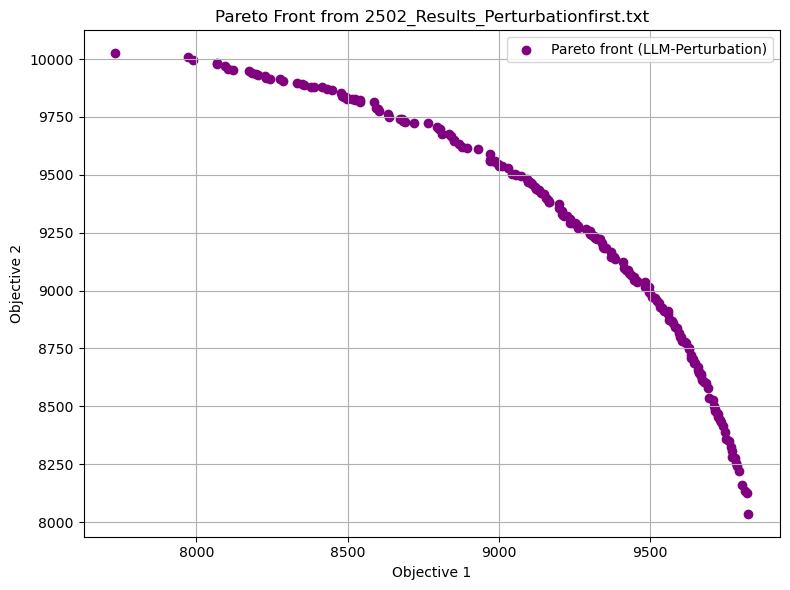


--- Comparison with Baseline ---

--- Results for 2502_ResultsMD.txt ---
  Total points generated: 1413
  Pareto-optimal points: 212

✅ ALL DONE!


In [76]:
# ============================================================================
# CELL 3: PYTHON STRATEGY PROVIDER AND EXECUTION - PERTURBATION (FIXED)
# ============================================================================

import requests
import json
import matplotlib.pyplot as plt
import time
import math

# ============================================================================
# NEW LLM STRATEGY PROVIDER - INTELLIGENT PERTURBATION (FIXED)
# ============================================================================

# In Cell 3, replace the `LLMStrategyProvider` class with this final version:

class LLMStrategyProvider:
    """
    Uses the LLM to suggest a strategic direction, with memory to avoid repetitive suggestions.
    """
    def __init__(self, model_name="llama3:8b", stagnation_threshold=20, nbitems=250):
        self.model_name = model_name
        self.stagnation_threshold = stagnation_threshold
        self.url = "http://localhost:11434/api/generate"
        self.ni = nbitems
        self.stagnation_counter = 0
        self.last_archive_size = 0
        self.llm_call_count = 0
        
        # NEW: Memory to store recently applied swaps
        self.recent_swaps = set()
        
        print(f"[PROVIDER] Initialized with model '{model_name}' and memory for guided suggestion.")

    def reset_for_run(self, run_id):
        """Reset state for a new run."""
        self.stagnation_counter = 0
        self.last_archive_size = 0
        self.recent_swaps.clear() # Clear memory for each new run
        print(f"[PROVIDER] --- Reset for Run {run_id} ---")

    def _query_llm_for_guidance(self, solution_info):
        """Queries the LLM for a strategic direction."""
        prompt = f"""You are an expert knapsack optimizer. The search is stuck.
Current solution performance: Profit1={solution_info['f1']:.2f}, Profit2={solution_info['f2']:.2f}.

To improve the Pareto front, should we focus on improving Objective 1 or Objective 2?
Reply with only the number: 1 (for Objective 1) or 2 (for Objective 2)."""

        payload = {
            "model": self.model_name,
            "prompt": prompt,
            "stream": False,
            "options": {"temperature": 0.2, "max_tokens": 5}
        }
        try:
            response = requests.post(self.url, json=payload, timeout=40)
            if response.status_code == 200:
                result = response.json()
                response_text = result.get('response', '').strip()
                for char in response_text:
                    if char.isdigit():
                        choice = int(char)
                        if choice == 1 or choice == 2:
                            return choice - 1 # Return 0 for obj1, 1 for obj2
                print(f"[PROVIDER] LLM Warning: Could not parse choice from '{response_text}'.")
                return None
            else:
                print(f"[PROVIDER] LLM Error: HTTP {response.status_code}")
                return None
        except requests.exceptions.RequestException as e:
            print(f"[PROVIDER] LLM Connection Error: {e}.")
            return None

    
    def get_strategy(self, iteration, archive_size, current_solution_for_perturbation):
        """Main method. Returns strategy 0 (default) or a guided suggestion dict."""
        if archive_size > self.last_archive_size:
            self.stagnation_counter = 0
            self.last_archive_size = archive_size
        else:
            self.stagnation_counter += 1
        
        if self.stagnation_counter < self.stagnation_threshold:
            return {'code': 0, 'reason': 'Default: Original Random Search'}
    
        print(f"\n[PROVIDER] *** STAGNATION DETECTED ***")
        print(f"[PROVIDER] Iteration: {iteration}, Archive Size: {archive_size}")
        
        # --- ADD THIS DIAGNOSTIC PRINT ---
        print(f"[PROVIDER] DIAGNOSTIC: Current Profits -> Obj1: {current_solution_for_perturbation['f1']:.2f}, Obj2: {current_solution_for_perturbation['f2']:.2f}")
        
        suggestion_type = self._query_llm_for_guidance(current_solution_for_perturbation)
        self.llm_call_count += 1
    
        if suggestion_type is not None:
            obj_name = "Objective 1" if suggestion_type == 0 else "Objective 2"
            print(f"[PROVIDER] LLM suggested focusing on: {obj_name}")
            self.stagnation_counter = 0
            return {
                'code': -1,
                'reason': f'LLM-guided suggestion for {obj_name}',
                'suggestion_type': suggestion_type,
                'memory': self.recent_swaps
            }
        else:
            print("[PROVIDER] LLM failed to provide guidance. Continuing with default strategy.")
            return {'code': 0, 'reason': 'Default: LLM failed, using original search'}

# ============================================================================
# VISUALIZATION AND ANALYSIS FUNCTIONS (Unchanged)
# ============================================================================

def dominates(a, b):
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def plot_pareto_front(filename, title_suffix=""):
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except:
                    pass
    if not points:
        print(f"No data to plot in {filename}")
        return
    pareto = get_true_pareto_front(points)
    xs, ys = zip(*pareto)
    plt.figure(figsize=(8,6))
    plt.scatter(xs, ys, color='purple', label=f"Pareto front {title_suffix}")
    plt.xlabel("Objective 1")
    plt.ylabel("Objective 2")
    plt.title(f"Pareto Front from {filename}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def report_pareto_stats(filename):
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except:
                    pass
    total_points = len(points)
    pareto_front = get_true_pareto_front(points)
    num_pareto = len(pareto_front)
    print(f"\n--- Results for {filename} ---")
    print(f"  Total points generated: {total_points}")
    print(f"  Pareto-optimal points: {num_pareto}")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("=" * 70)
    print("HYBRID LLM-MOACP EXECUTION - INTELLIGENT PERTURBATION")
    print("=" * 70)
    
    # FIX: Pass nbitems to the provider's constructor
    nbitems = 250
    llm_perturb_provider = LLMStrategyProvider(
        model_name="llama3:8b", 
        stagnation_threshold=5, 
        nbitems=nbitems
    )
    
    # Run hybrid MOACP with the perturbation provider
    print("\n--- Starting LLM-Perturbation-guided MOACP execution ---\n")
    
    start_time = time.time()
    
    run_hybrid_moacp(
        instance_file=b"250.2.txt",
        weights_file=b"Weights_2obj_FQ200.txt",
        nbitems=nbitems,
        num_objectives=2,
        output_file="2502_Results_Perturbationfirst.txt",  # New output file
        strategy_provider=llm_perturb_provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n--- Execution finished in {elapsed:.1f}s ({elapsed/60:.2f} min) ---")
    print(f"--- Total LLM calls made: {llm_perturb_provider.llm_call_count} ---\n")
    
    # Report statistics for the perturbation run
    report_pareto_stats("2502_Results_Perturbationfirst.txt")
    
    # Plot results for the perturbation run
    print("\n--- Plotting results ---")
    plot_pareto_front("2502_Results_Perturbationfirst.txt", title_suffix="(LLM-Perturbation)")
    
    # Compare with baseline
    print("\n--- Comparison with Baseline ---")
    report_pareto_stats("2502_ResultsMD.txt")  # Baseline
    
    print("\n✅ ALL DONE!")

In [43]:
# Compare with baseline
print("\n--- Comparison with Baseline ---")
report_pareto_stats("2502_ResultsMD.txt")  # Baseline
report_pareto_stats("2502_Results_Perturbation1.txt")  # Hybrid


--- Comparison with Baseline ---

--- Results for 2502_ResultsMD.txt ---
  Total points generated: 1413
  Pareto-optimal points: 212

--- Results for 2502_Results_Perturbation1.txt ---
  Total points generated: 1403
  Pareto-optimal points: 207


In [44]:
import matplotlib.pyplot as plt

# --- Helper Functions (to find the true Pareto front) ---

def dominates(a, b):
    """
    Returns True if solution 'a' dominates solution 'b'.
    Assumes both objectives are to be maximized.
    """
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """
    Filters a list of points to return only the non-dominated ones (the true Pareto front).
    """
    pareto_front = []
    for i, p in enumerate(points):
        is_dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                is_dominated = True
                break
        if not is_dominated:
            pareto_front.append(p)
    return pareto_front

# --- Main Plotting Function ---

def plot_comparison_pareto(filename1, filename2, title1, title2):
    """
    Reads two result files, extracts their Pareto fronts, and plots them on the same graph.

    Args:
        filename1 (str): Path to the first result file (e.g., the baseline).
        filename2 (str): Path to the second result file (e.g., the hybrid).
        title1 (str): A descriptive name for the first algorithm (for the legend).
        title2 (str): A descriptive name for the second algorithm (for the legend).
    """
    # --- Read and process the first file ---
    points1 = []
    with open(filename1, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points1.append([float(x) for x in line.split()])
                except ValueError:
                    # Skip lines that are not valid numbers
                    pass
    pareto1 = get_true_pareto_front(points1)
    xs1, ys1 = zip(*pareto1) # Unzip the list of (x, y) pairs into two lists

    # --- Read and process the second file ---
    points2 = []
    with open(filename2, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points2.append([float(x) for x in line.split()])
                except ValueError:
                    pass
    pareto2 = get_true_pareto_front(points2)
    xs2, ys2 = zip(*pareto2) # Unzip the list of (x, y) pairs into two lists

    # --- Create the plot ---
    plt.figure(figsize=(10, 8))

    # Plot the first Pareto front
    plt.scatter(xs1, ys1, color='blue', alpha=0.7, label=f'{title1} ({len(pareto1)} points)', marker='o')

    # Plot the second Pareto front
    plt.scatter(xs2, ys2, color='red', alpha=0.7, label=f'{title2} ({len(pareto2)} points)', marker='x')

    # Add labels, title, and legend
    plt.xlabel("Objective 1 (Profit 1)")
    plt.ylabel("Objective 2 (Profit 2)")
    plt.title("Pareto Front Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


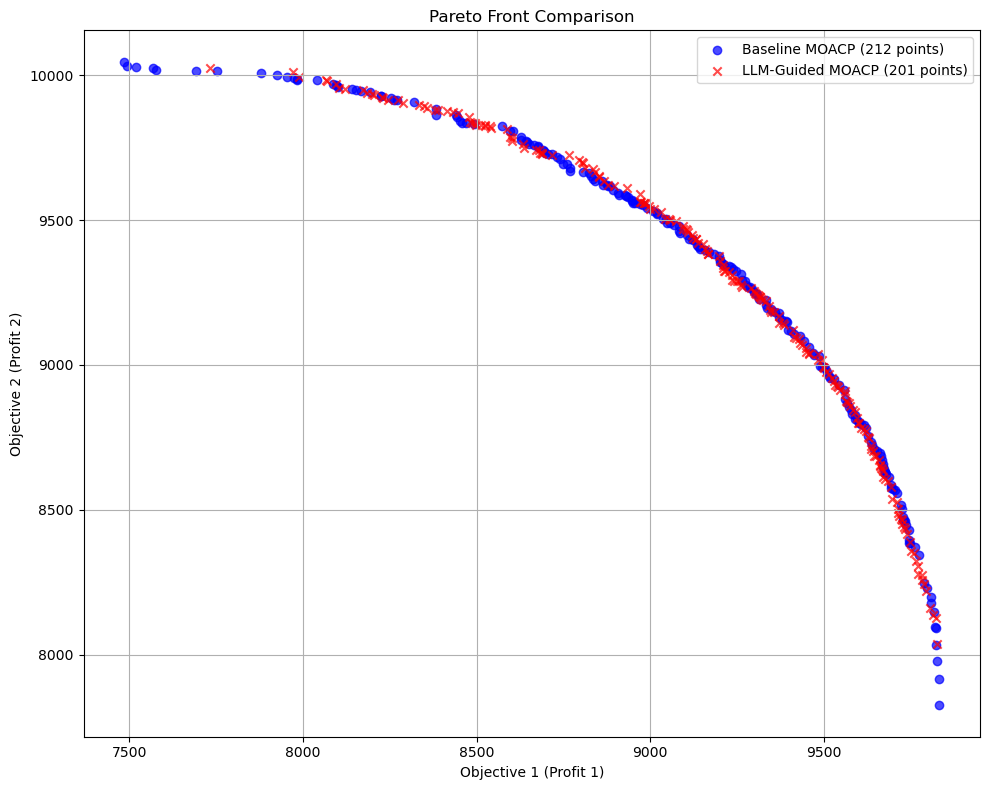

In [77]:
# Call the function with your file names and descriptive titles
plot_comparison_pareto(
    filename1="2502_ResultsMD.txt",
    filename2="2502_Results_Perturbationfirst.txt",
    title1="Baseline MOACP",
    title2="LLM-Guided MOACP"
)

HYBRID LLM-MOACP EXECUTION - 500 ITEM INSTANCE
[PROVIDER] Initialized with model 'llama3:8b' and memory for guided suggestion.

--- Starting LLM-Perturbation-guided MOACP execution on 500 items ---


========== RUN 1/10 ==========
Instance: 500.2.txt, Items: 500, Objectives: 2
[PROVIDER] --- Reset for Run 1 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 6, Archive Size: 2
[PROVIDER] DIAGNOSTIC: Current Profits -> Obj1: 16262.00, Obj2: 20425.00
[PROVIDER] LLM suggested focusing on: Objective 2
[CYTHON] Applying LLM-guided suggestion...
[CYTHON] LLM-guided swap applied: REMOVED 38, ADDED 56 with gain 90.00

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 52, Archive Size: 253
[PROVIDER] DIAGNOSTIC: Current Profits -> Obj1: 16262.00, Obj2: 20425.00
[PROVIDER] LLM suggested focusing on: Objective 2
[CYTHON] Applying LLM-guided suggestion...
[CYTHON] LLM-guided swap applied: REMOVED 418, ADDED 56 with gain 90.00

[PROVIDER] *** STAGNATION DETECTED ***
[PROVID

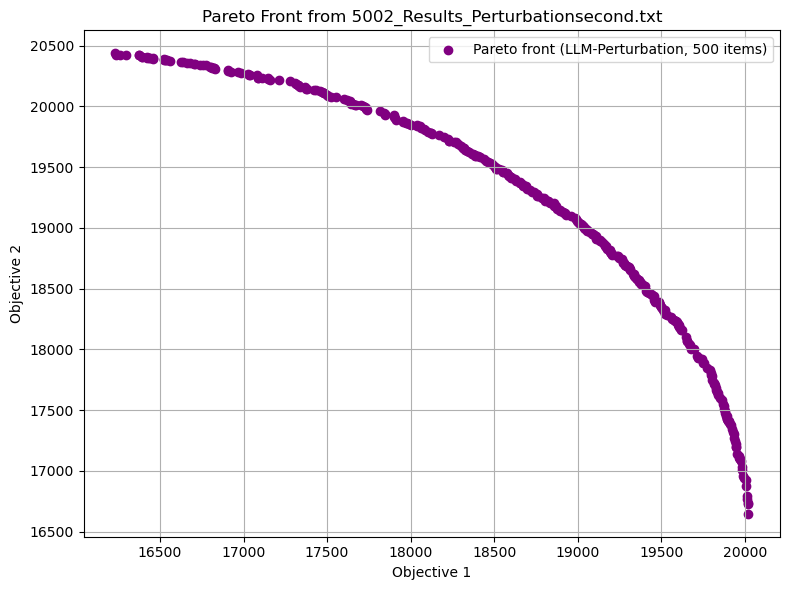


--- Comparison with Baseline (500 items) ---

--- Results for 5002_ResultsMD.txt ---
  Total points generated: 2241
  Pareto-optimal points: 369

✅ ALL DONE!


In [78]:
# In Cell 3, at the bottom of the script

if __name__ == "__main__":
    print("=" * 70)
    print("HYBRID LLM-MOACP EXECUTION - 500 ITEM INSTANCE")
    print("=" * 70)
    
    # --- CHANGE THESE PARAMETERS ---
    nbitems = 500
    instance_file = b"500.2.txt"
    output_file = "5002_Results_Perturbationsecond.txt"
    
    llm_perturb_provider = LLMStrategyProvider(
        model_name="llama3:8b", 
        stagnation_threshold=5, # Keep the best-performing threshold
        nbitems=nbitems
    )
    
    print("\n--- Starting LLM-Perturbation-guided MOACP execution on 500 items ---\n")
    
    start_time = time.time()
    
    run_hybrid_moacp(
        instance_file=instance_file,
        weights_file=b"Weights_2obj_FQ200.txt", # This file is the same for 2-objective problems
        nbitems=nbitems,
        num_objectives=2,
        output_file=output_file,
        strategy_provider=llm_perturb_provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n--- Execution finished in {elapsed:.1f}s ({elapsed/60:.2f} min) ---")
    print(f"--- Total LLM calls made: {llm_perturb_provider.llm_call_count} ---\n")
    
    # Report statistics for the new run
    report_pareto_stats(output_file)
    
    # Plot results for the new run
    print("\n--- Plotting results ---")
    plot_pareto_front(output_file, title_suffix="(LLM-Perturbation, 500 items)")
    
    # Compare with baseline for the 500-item instance
    print("\n--- Comparison with Baseline (500 items) ---")
    report_pareto_stats("5002_ResultsMD.txt")  # Baseline for 500 items
    
    print("\n✅ ALL DONE!")

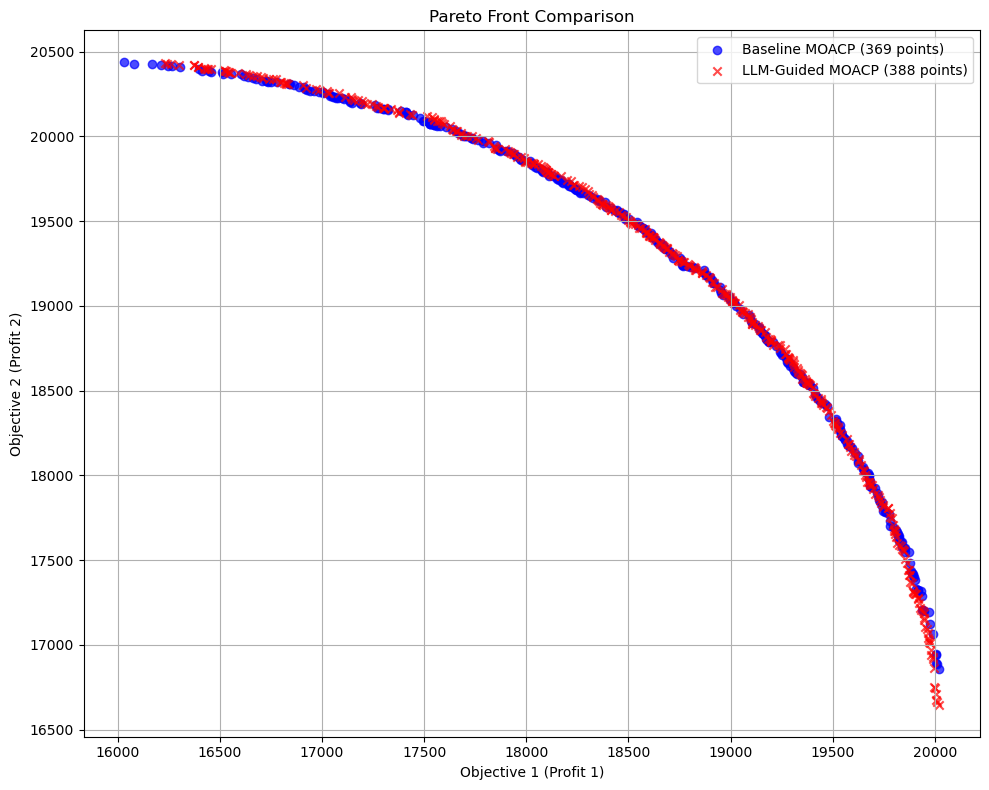

In [73]:
# Call the function with your file names and descriptive titles
plot_comparison_pareto(
    filename1="5002_ResultsMD.txt",
    filename2="5002_Results_Perturbation_Final.txt",
    title1="Baseline MOACP",
    title2="LLM-Guided MOACP"
)

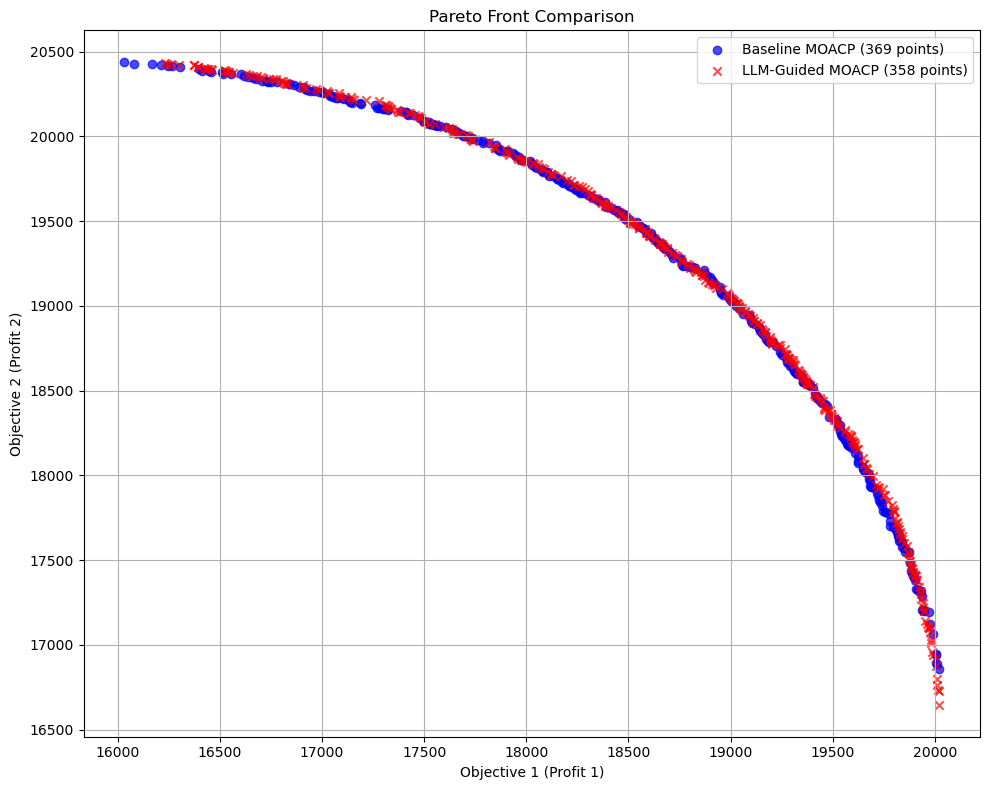

In [79]:
# Call the function with your file names and descriptive titles
plot_comparison_pareto(
    filename1="5002_ResultsMD.txt",
    filename2="5002_Results_Perturbationsecond.txt",
    title1="Baseline MOACP",
    title2="LLM-Guided MOACP"
)

HYBRID LLM-MOACP EXECUTION - 750 ITEM INSTANCE
[PROVIDER] Initialized with model 'llama3:8b' and memory for guided suggestion.

--- Starting LLM-Perturbation-guided MOACP execution on 750 items ---


========== RUN 1/10 ==========
Instance: 750.2.txt, Items: 750, Objectives: 2
[PROVIDER] --- Reset for Run 1 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 56, Archive Size: 345
[PROVIDER] DIAGNOSTIC: Current Profits -> Obj1: 23785.00, Obj2: 29881.00
[PROVIDER] LLM suggested focusing on: Objective 2
[CYTHON] Applying LLM-guided suggestion...
[CYTHON] LLM-guided swap applied: REMOVED 541, ADDED 176 with gain 87.00

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 63, Archive Size: 349
[PROVIDER] DIAGNOSTIC: Current Profits -> Obj1: 23785.00, Obj2: 29881.00
[PROVIDER] LLM suggested focusing on: Objective 2
[CYTHON] Applying LLM-guided suggestion...
[CYTHON] LLM-guided swap applied: REMOVED 469, ADDED 327 with gain 86.00

[PROVIDER] *** STAGNATION DETECTED ***
[

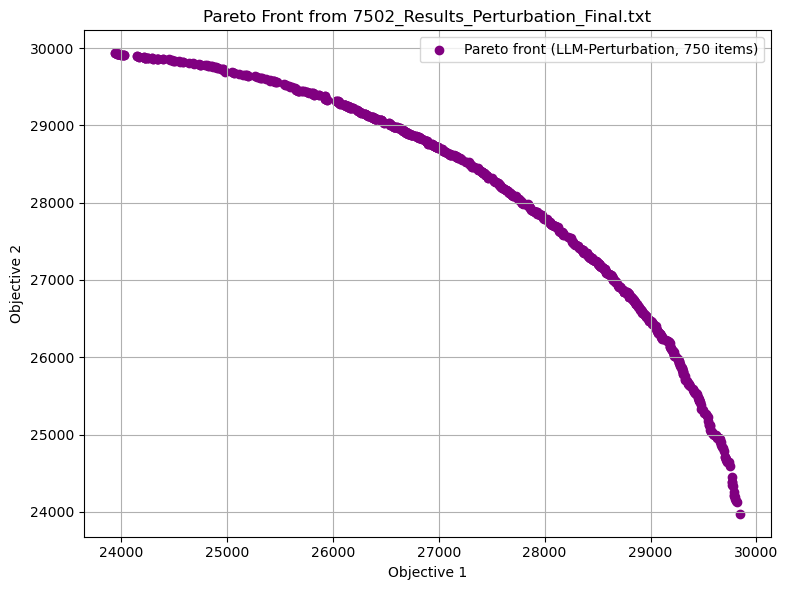


--- Comparison with Baseline (750 items) ---

--- Results for 7502_ResultsMD.txt ---
  Total points generated: 2927
  Pareto-optimal points: 552

✅ ALL DONE!


In [80]:
# In Cell 3, at the bottom of the script

if __name__ == "__main__":
    print("=" * 70)
    print("HYBRID LLM-MOACP EXECUTION - 750 ITEM INSTANCE")
    print("=" * 70)
    
    # --- CHANGE THESE PARAMETERS ---
    nbitems = 750
    instance_file = b"750.2.txt"
    output_file = "7502_Results_Perturbation_Final.txt"
    
    llm_perturb_provider = LLMStrategyProvider(
        model_name="llama3:8b", 
        stagnation_threshold=5, # Keep the best-performing threshold
        nbitems=nbitems
    )
    
    print("\n--- Starting LLM-Perturbation-guided MOACP execution on 750 items ---\n")
    
    start_time = time.time()
    
    run_hybrid_moacp(
        instance_file=instance_file,
        weights_file=b"Weights_2obj_FQ200.txt", # This file is the same for 2-objective problems
        nbitems=nbitems,
        num_objectives=2,
        output_file=output_file,
        strategy_provider=llm_perturb_provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n--- Execution finished in {elapsed:.1f}s ({elapsed/60:.2f} min) ---")
    print(f"--- Total LLM calls made: {llm_perturb_provider.llm_call_count} ---\n")
    
    # Report statistics for the new run
    report_pareto_stats(output_file)
    
    # Plot results for the new run
    print("\n--- Plotting results ---")
    plot_pareto_front(output_file, title_suffix="(LLM-Perturbation, 750 items)")
    
    # Compare with baseline for the 750-item instance
    print("\n--- Comparison with Baseline (750 items) ---")
    report_pareto_stats("7502_ResultsMD.txt")  # Baseline for 750 items
    
    print("\n✅ ALL DONE!")

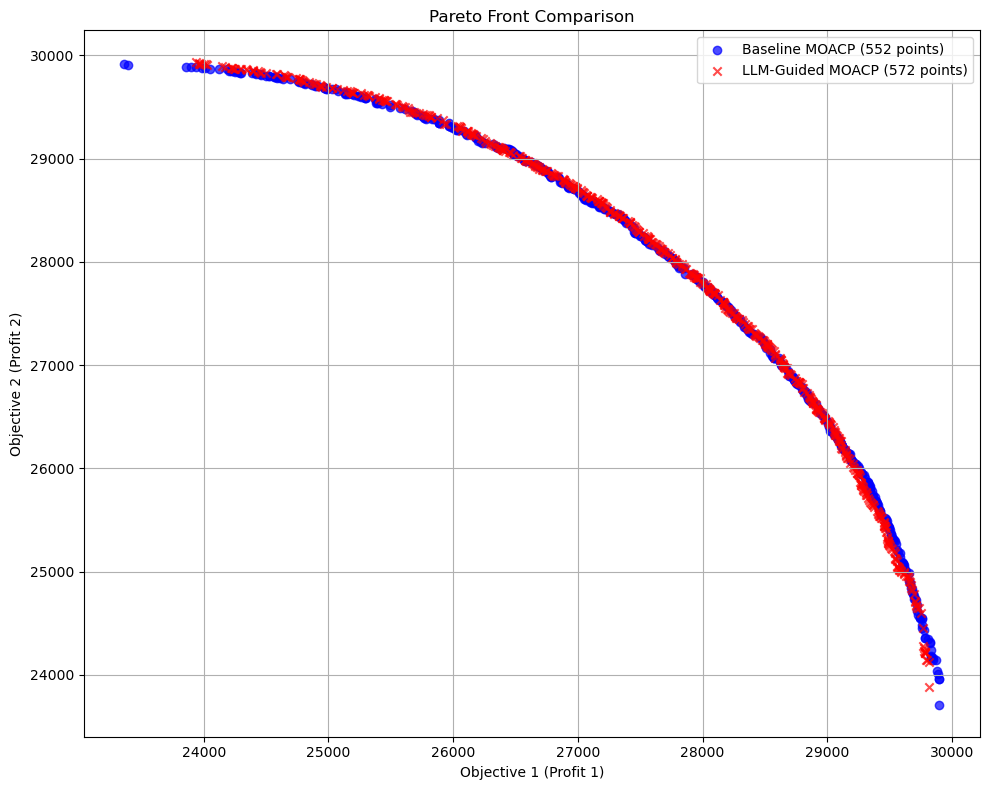

In [75]:
# Call the function with your file names and descriptive titles
plot_comparison_pareto(
    filename1="7502_ResultsMD.txt",
    filename2="7502_Results_Perturbation_Final.txt",
    title1="Baseline MOACP",
    title2="LLM-Guided MOACP"
)

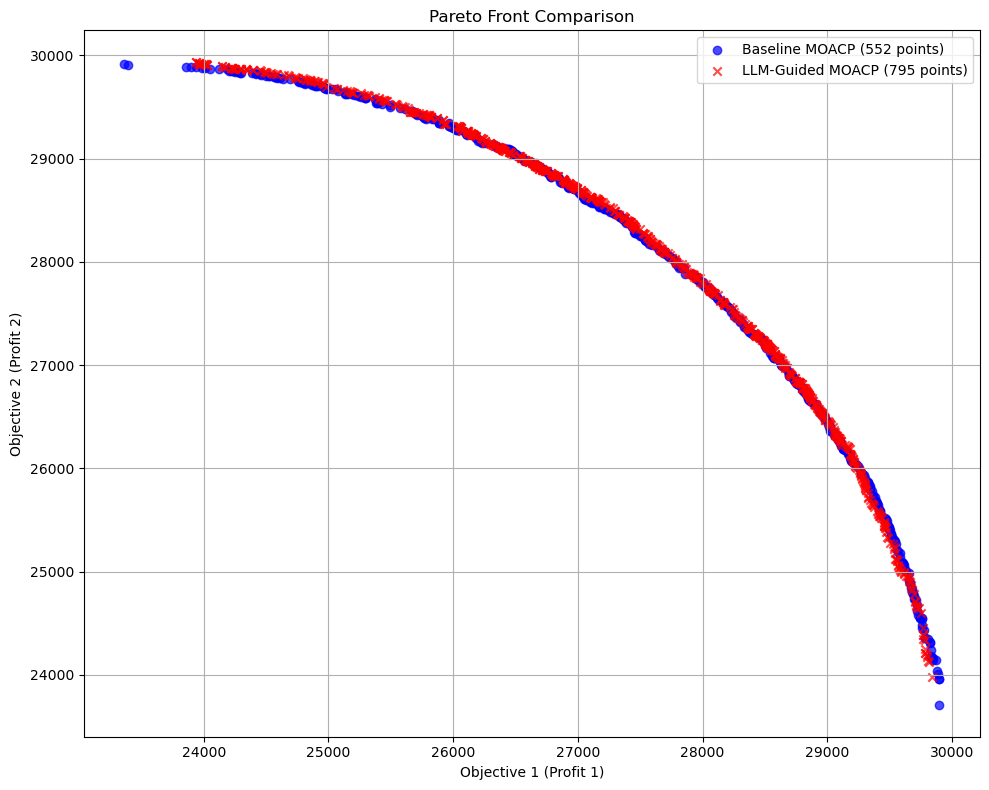

In [81]:
# Call the function with your file names and descriptive titles
plot_comparison_pareto(
    filename1="7502_ResultsMD.txt",
    filename2="7502_Results_Perturbation_Final.txt",
    title1="Baseline MOACP",
    title2="LLM-Guided MOACP"
)